# Wine Quality Classification , Exploratory Data Analysis

In this analysis, the UCI Red Wine Quality dataset is examined to investigate how different chemical properties of wine relate to its overall quality rating and to determine a suitable way to transform the target variable for modeling.

The dataset contains 1,599 samples of red wine, each described by 11 physicochemical attributes such as acidity, sugar content, sulphates, and alcohol level. Alongside these features, each wine has a quality score ranging from 0 to 10, assigned through sensory evaluation.

For the purpose of this project, the quality score is converted into a binary classification problem. Wines with a score of 7 or higher are labeled as “good wine,” while those with scores below 7 are considered “not good.” This transformation simplifies the prediction task and allows us to focus on distinguishing higher-quality wines from the rest.

## 1) Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set basic plot style
sns.set_style("whitegrid")

# make plots a bit bigger
plt.rcParams["figure.figsize"] = (10,6)

# show plots inside notebook
%matplotlib inline





## 2) Load Data

In [22]:
# read dataset
df = pd.read_csv("data/winequality-red.csv")

# check dataset size and preview first rows
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3) Dataset Overview

In [23]:
# a quick look at column types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [24]:
df.describe().round(3)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [25]:
# check duplicates and missing values
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")

Duplicate rows: 240
Missing values : 0


## 4) Quality distribution

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19260\2198357379.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis", ax=axes[0])


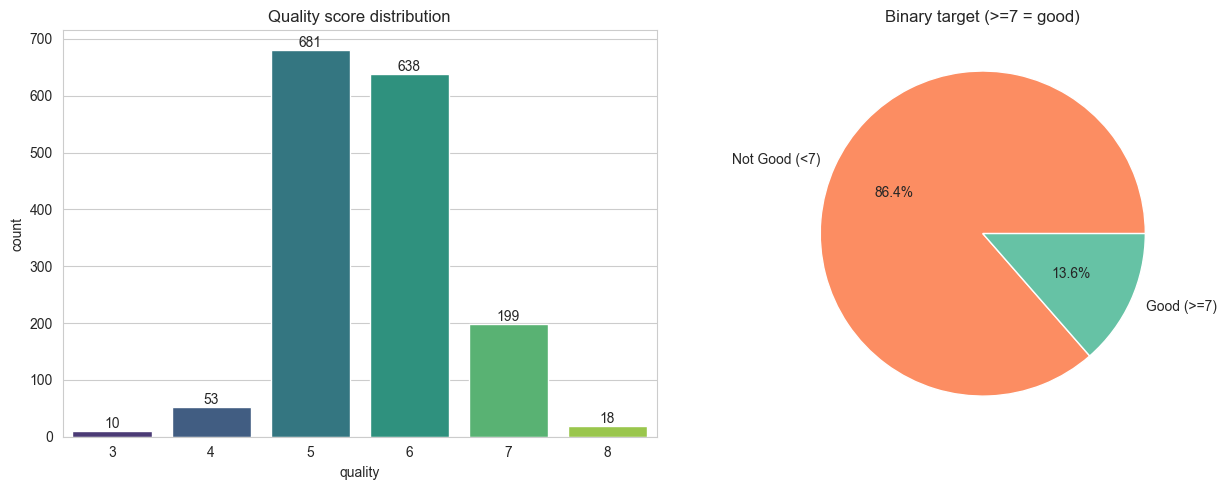

good_quality
0    1382
1     217
Name: count, dtype: int64


In [26]:

fig, axes = plt.subplots(1,2, figsize=(13,5))

# count of each quality score
sns.countplot(x="quality", data=df, palette="viridis", ax=axes[0])
axes[0].set_title("Quality score distribution")

# write counts above bars
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        int(height),
        (p.get_x() + p.get_width()/2, height),
        ha="center",
        va="bottom"
    )

# create binary label: good wine or not
df["good_quality"] = (df["quality"] >= 7).astype(int)

# show ratio of good vs not good
df["good_quality"].value_counts().plot.pie(
    labels=["Not Good (<7)", "Good (>=7)"],
    autopct="%1.1f%%",
    colors=["#fc8d62", "#66c2a5"],
    ax=axes[1]
)

axes[1].set_ylabel("")
axes[1].set_title("Binary target (>=7 = good)")

plt.tight_layout()
plt.show()

# print counts
print(df["good_quality"].value_counts())


## 5) Feature Distributions

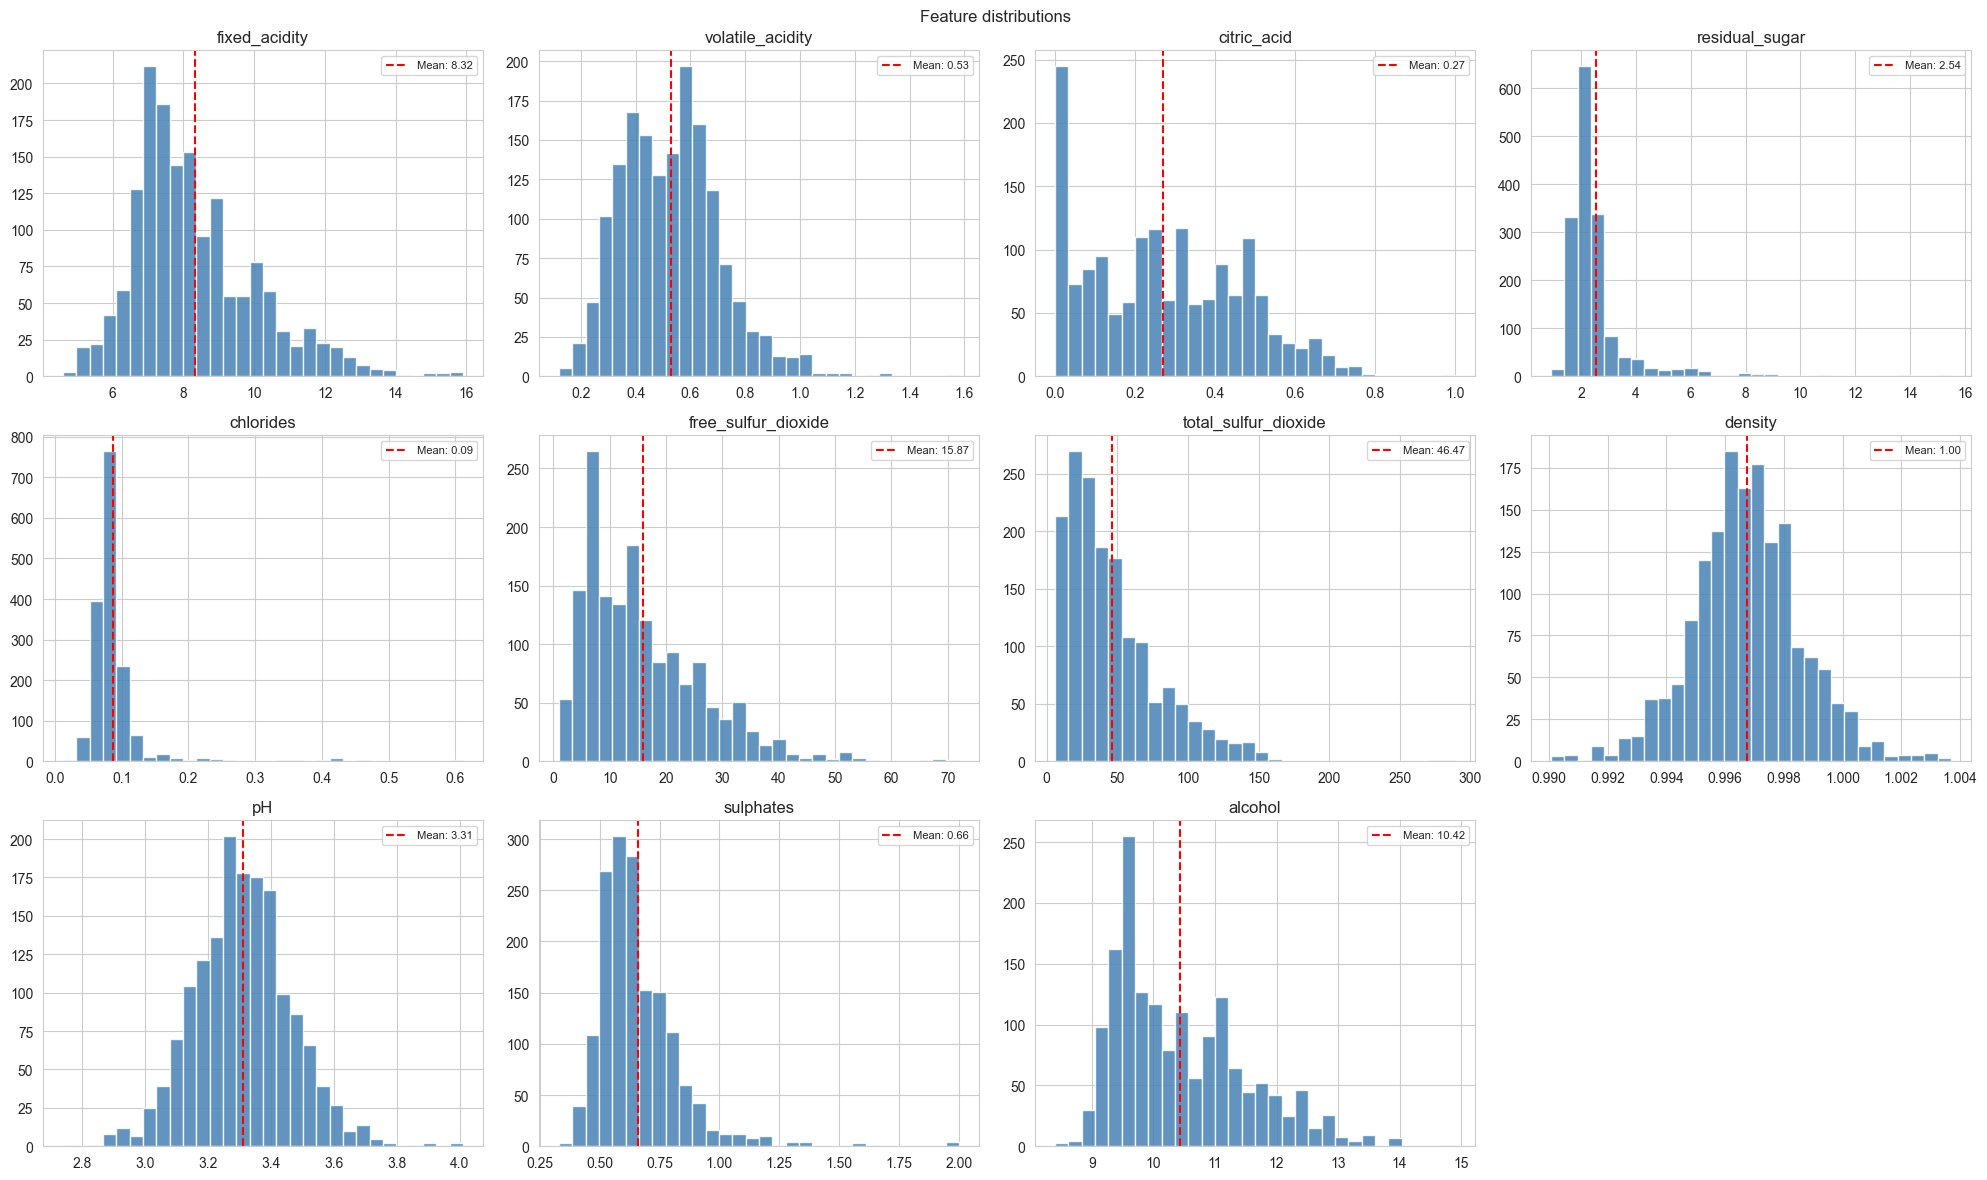

In [27]:

# remove target columns
features = [c for c in df.columns if c not in ["quality", "good_quality"]]

fig, axes = plt.subplots(3,4, figsize=(20,12))
axes = axes.flatten()

for i, col in enumerate(features):

    # histogram for each feature
    axes[i].hist(
        df[col],
        bins=30,
        color="steelblue",
        edgecolor="white",
        alpha=0.85
    )

    # mark mean value
    axes[i].axvline(
        df[col].mean(),
        color="red",
        linestyle="--",
        label=f"Mean: {df[col].mean():.2f}"
    )

    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# hide extra empty plots
for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Feature distributions")
plt.tight_layout()
plt.show()


**Boxplots to detect outliers**

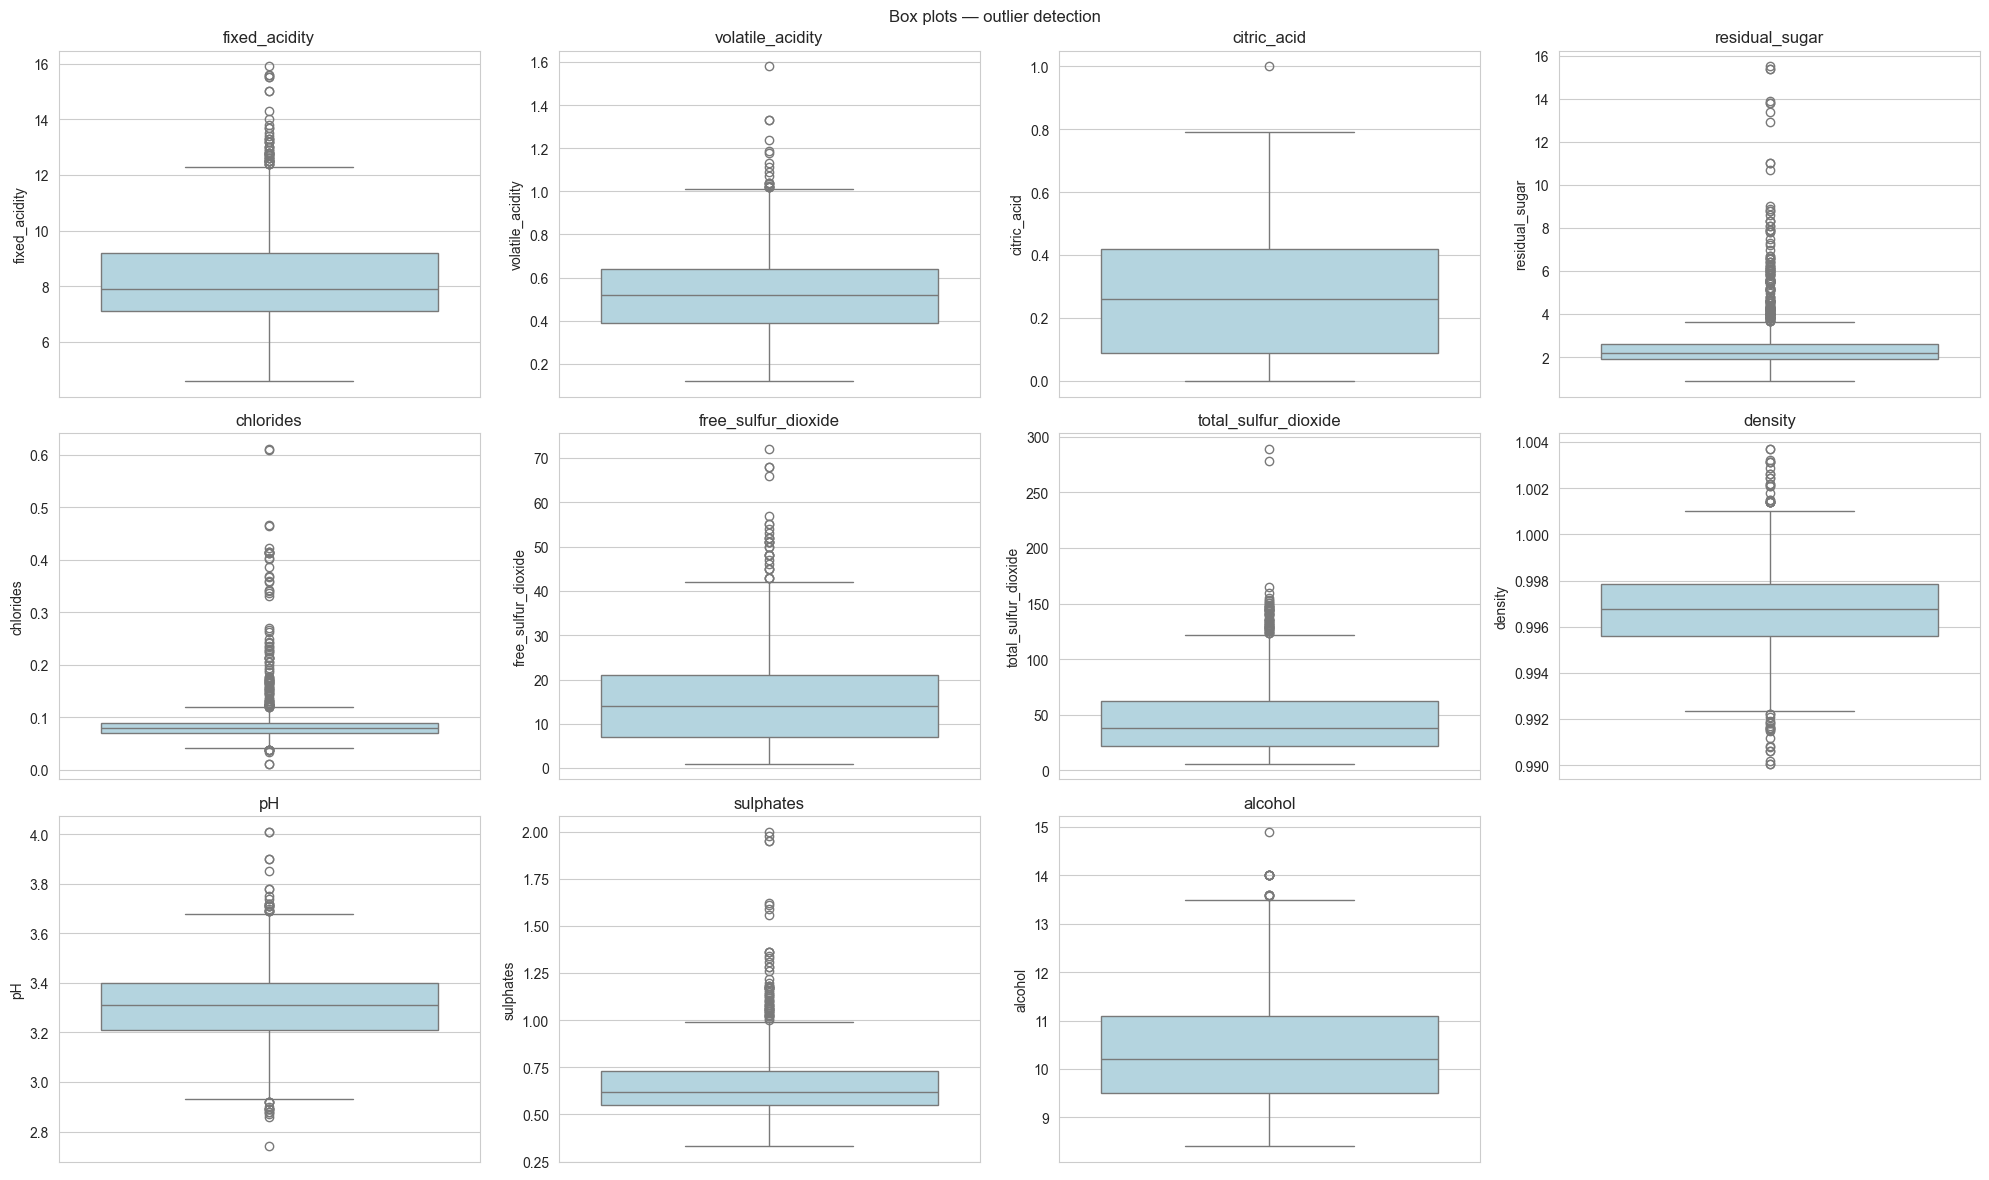

In [28]:


fig, axes = plt.subplots(3,4, figsize=(20,12))
axes = axes.flatten()

for i, col in enumerate(features):

    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="lightblue"
    )

    axes[i].set_title(col)

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Box plots — outlier detection")
plt.tight_layout()
plt.show()



## 6) Compare feature distributions for good vs bad wine

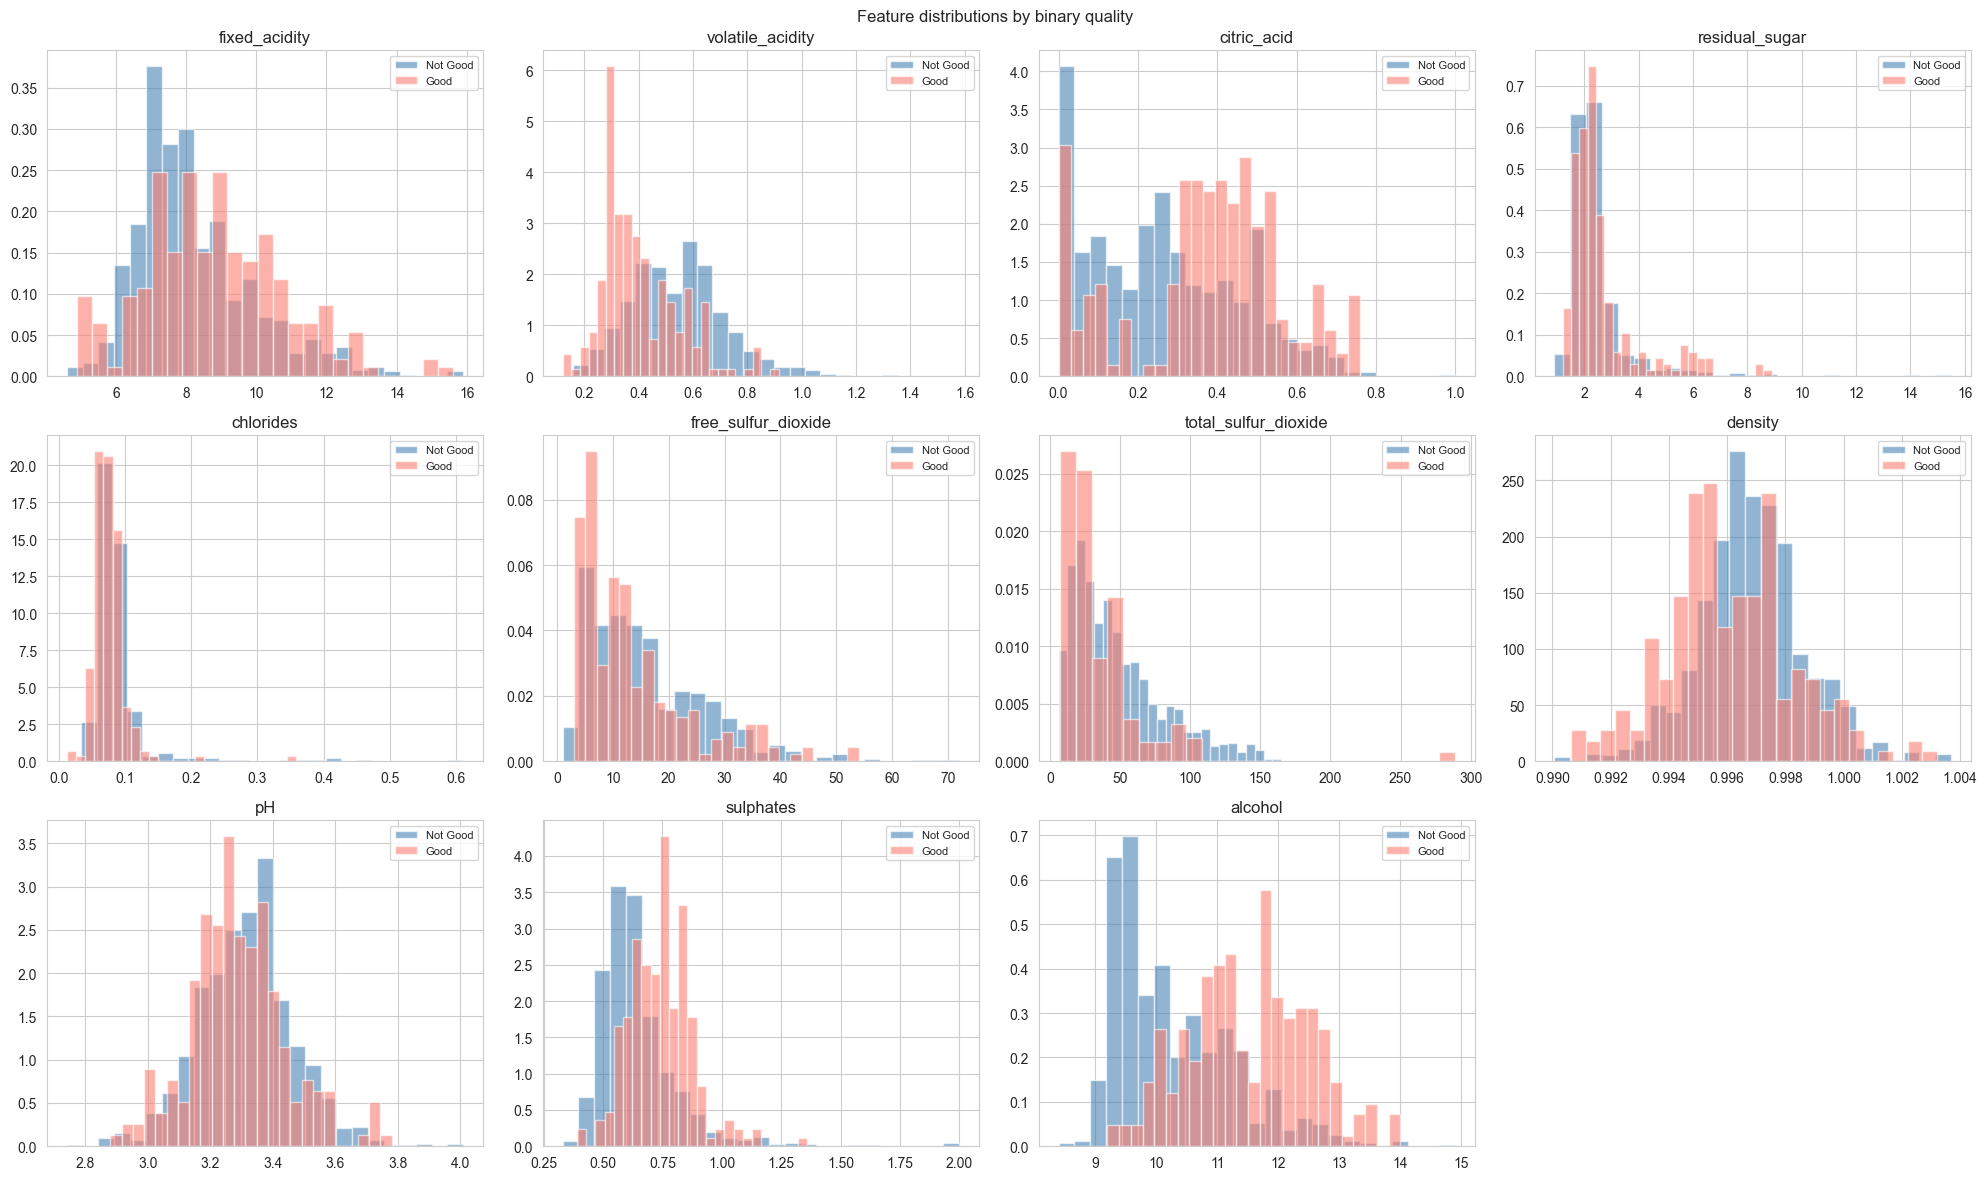

In [29]:

fig, axes = plt.subplots(3,4, figsize=(20,12))
axes = axes.flatten()

for i, col in enumerate(features):

    # wines with low quality
    subset_bad = df[df["good_quality"] == 0][col]

    # wines with good quality
    subset_good = df[df["good_quality"] == 1][col]

    axes[i].hist(subset_bad, bins=25, alpha=0.6,
                 color="steelblue", label="Not Good", density=True)

    axes[i].hist(subset_good, bins=25, alpha=0.6,
                 color="salmon", label="Good", density=True)

    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(len(features), len(axes)):
    axes[j].axis("off")

plt.suptitle("Feature distributions by binary quality")
plt.tight_layout()
plt.show()


**Mean comparison between good and bad wine**

In [30]:

comparison = df.groupby("good_quality")[features].mean().T

comparison.columns = ["Not Good", "Good"]

# difference between the two groups
comparison["Difference"] = comparison["Good"] - comparison["Not Good"]

# percentage change
comparison["% Higher"] = (
    comparison["Difference"] / comparison["Not Good"] * 100
).round(1)

# sort by biggest difference
comparison.round(3).sort_values("% Higher", ascending=False)

,Not Good,Good,Difference,% Higher
citric_acid,0.254,0.376,0.122,48.0
sulphates,0.645,0.743,0.099,15.3
alcohol,10.251,11.518,1.267,12.4
residual_sugar,2.512,2.709,0.197,7.8
fixed_acidity,8.237,8.847,0.610,7.4
density,0.997,0.996,-0.001,-0.1
pH,3.315,3.289,-0.026,-0.8
free_sulfur_dioxide,16.172,13.982,-2.191,-13.5
chlorides,0.089,0.076,-0.013,-15.0
volatile_acidity,0.547,0.406,-0.141,-25.9


**Violin plots for some important features**

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19260\3370724853.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19260\3370724853.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Not Good", "Good"])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19260\3370724853.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19260\3370724853.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["

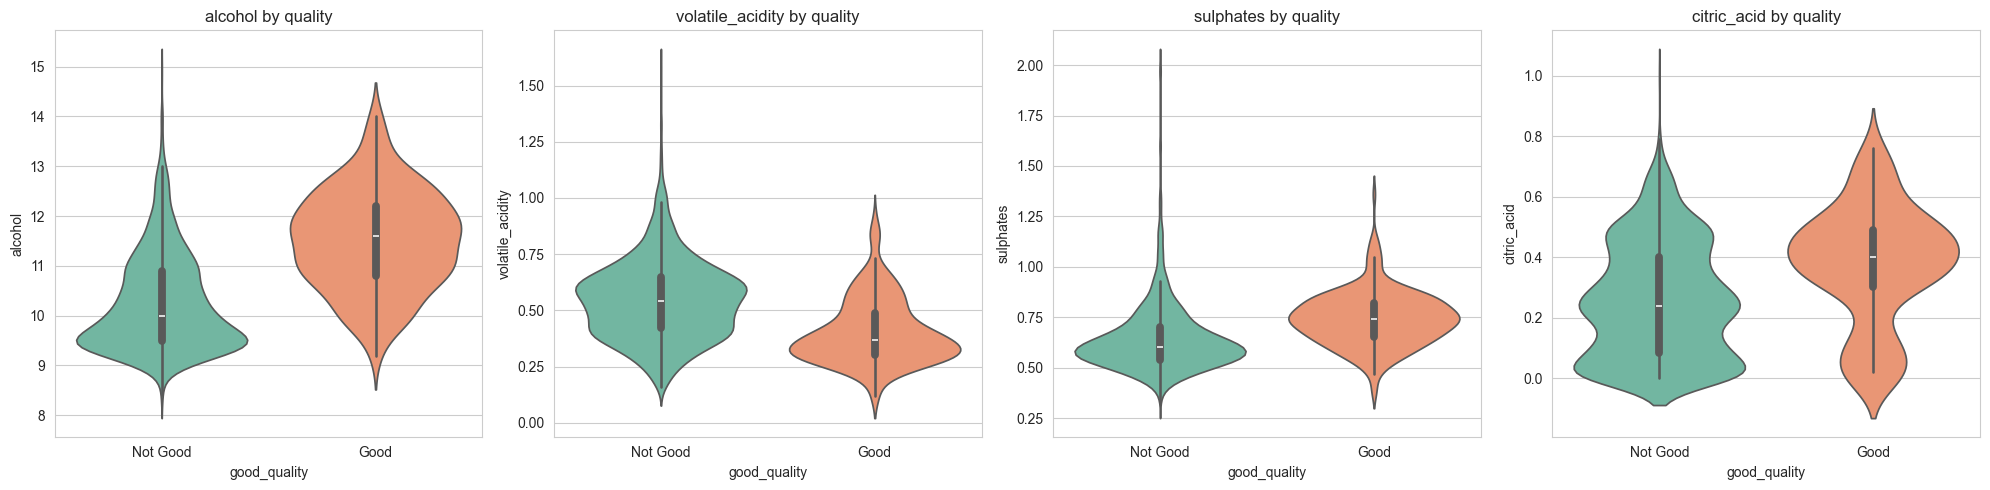

In [31]:

key_features = ["alcohol", "volatile_acidity", "sulphates", "citric_acid"]

fig, axes = plt.subplots(1, 4, figsize=(20,5))

for i, col in enumerate(key_features):

    sns.violinplot(
        x="good_quality",
        y=col,
        data=df,
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_xticklabels(["Not Good", "Good"])
    axes[i].set_title(col + " by quality")

plt.tight_layout()
plt.show()


## 7) Correlation Analysis

**Correlation heatmap**

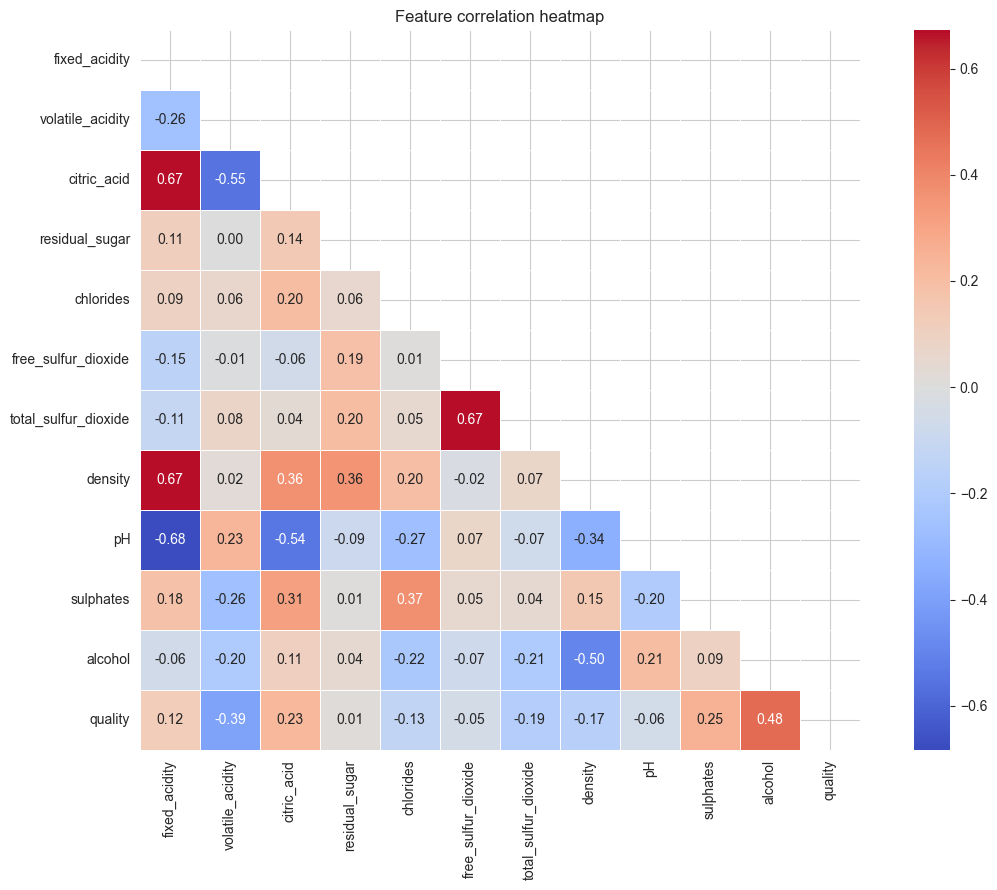

In [32]:

plt.figure(figsize=(12,9))

# drop binary column to avoid duplicate info
corr = df.drop(columns=["good_quality"]).corr()

# create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()



**Correlation with binary target**

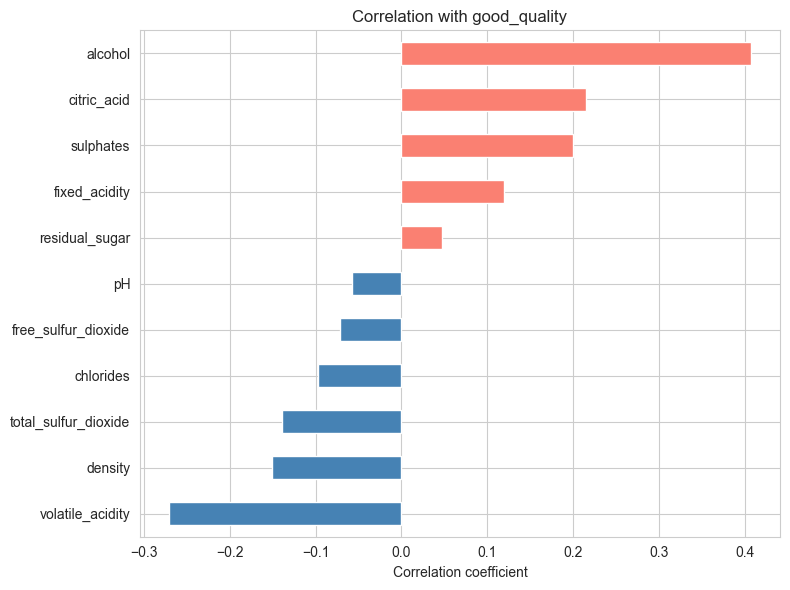

alcohol                 0.407
citric_acid             0.215
sulphates               0.199
fixed_acidity           0.120
residual_sugar          0.048
pH                     -0.057
free_sulfur_dioxide    -0.072
chlorides              -0.097
total_sulfur_dioxide   -0.140
density                -0.150
volatile_acidity       -0.271
Name: good_quality, dtype: float64


In [33]:

target_corr = df.corr()["good_quality"] \
                .drop(["good_quality", "quality"]) \
                .sort_values(ascending=False)

plt.figure(figsize=(8,6))

colors = ["salmon" if val > 0 else "steelblue" for val in target_corr]

target_corr.plot(kind="barh", color=colors)

plt.title("Correlation with good_quality")
plt.xlabel("Correlation coefficient")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(target_corr.round(3))


## 8)  Alcohol vs Volatile Acidity

**Scatter plot**

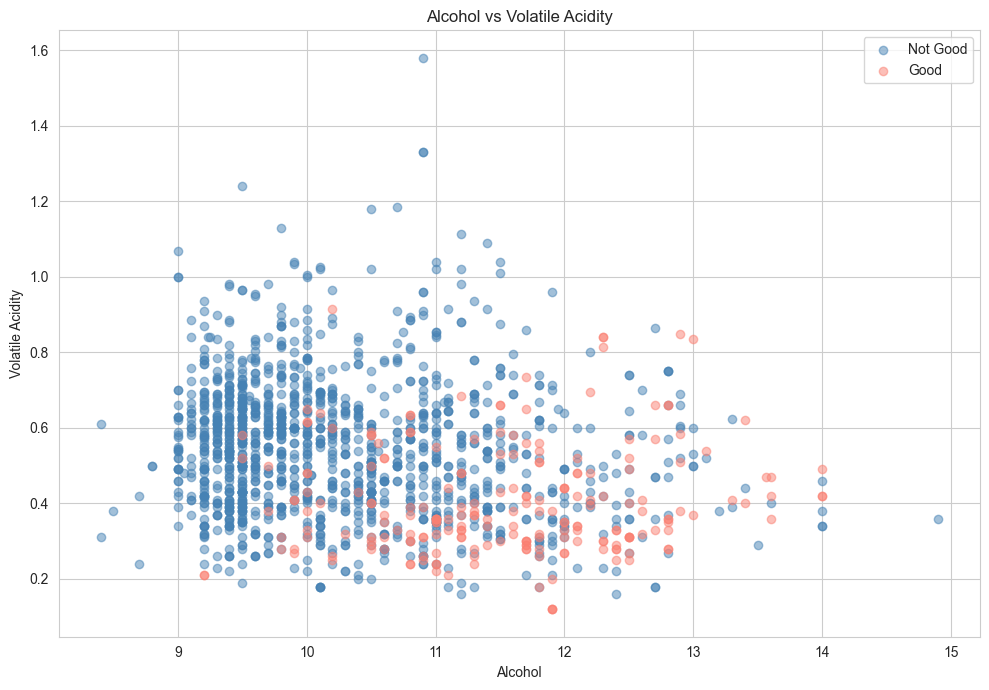

In [34]:

plt.figure(figsize=(10,7))

for label_value, color, name in [(0, "steelblue", "Not Good"),
                                 (1, "salmon", "Good")]:

    subset = df[df["good_quality"] == label_value]

    plt.scatter(
        subset["alcohol"],
        subset["volatile_acidity"],
        c=color,
        alpha=0.5,
        label=name
    )

plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.title("Alcohol vs Volatile Acidity")
plt.legend()

plt.tight_layout()
plt.show()


**Check good wine percentage by alcohol range**

In [35]:

print("Good-wine rate by alcohol bucket:")

buckets = [
    ("low (<9.5)", 0, 9.5),
    ("medium (9.5-11)", 9.5, 11),
    ("high (>=11)", 11, 20)
]

for label, low, high in buckets:

    subset = df[(df["alcohol"] >= low) & (df["alcohol"] < high)]

    if len(subset) > 0:

        rate = subset["good_quality"].mean() * 100

        print(f"{label:18s}: {rate:.1f}%   (n={len(subset)})")


Good-wine rate by alcohol bucket:
low (<9.5)        : 0.7%   (n=297)
medium (9.5-11)   : 7.3%   (n=835)
high (>=11)       : 33.0%   (n=467)


## 9) Pairplot for most important features

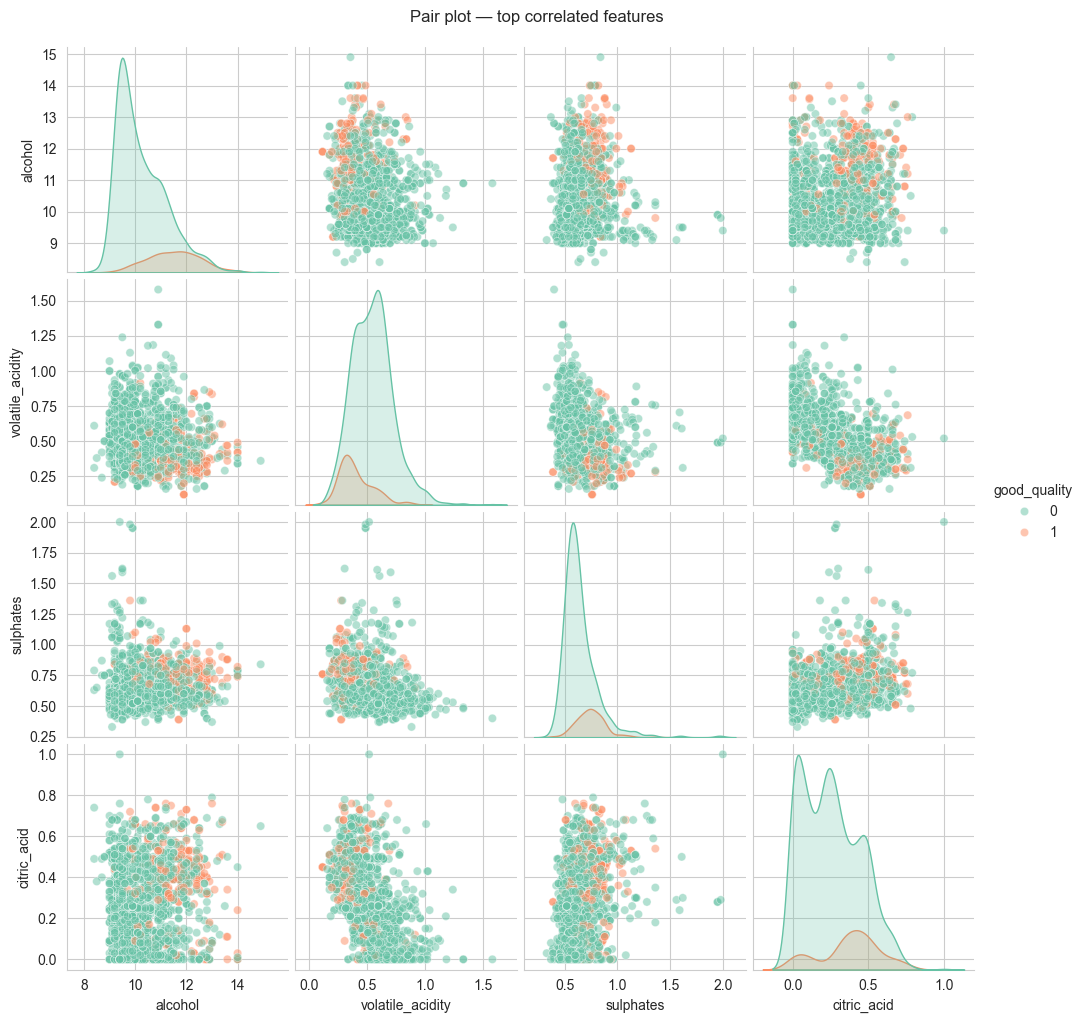

In [36]:

top_features = [
    "alcohol",
    "volatile_acidity",
    "sulphates",
    "citric_acid",
    "good_quality"
]

sns.pairplot(
    df[top_features],
    hue="good_quality",
    palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.5}
)

plt.suptitle("Pair plot — top correlated features", y=1.02)
plt.show()

## 10)  Key EDA Findings
#### 	Finding
1 	Class imbalance: only ~13.6% of wines score ≥7 — the binary target is heavily skewed

2 	Alcohol (r ≈ 0.48) is the single strongest linear predictor , good wines average ~11.5% ABV vs ~10.2% for not-good

3 	Volatile acidity (r ≈ −0.39) is the strongest negative predictor , vinegar character ruins quality

4 	Sulphates (r ≈ 0.25) and citric acid (r ≈ 0.22) also correlate positively with good wines

5 	Density and fixed acidity are highly intercorrelated , expect multicollinearity

6 	No missing values, but several features (residual sugar, chlorides, sulphates) have heavy right-tails , outliers worth noting

7 	Quality scores cluster at 5–6 , the dataset is dominated by mid-quality wines, and a >=7 cutoff yields the cleanest "good vs not-good" split